# 11 — PCA (Kaggle-specialised)

Sibling to NB 11. Same PCA recipe, but trained on the **Kaggle preprocessing** (`data/processed/kaggle/`) rather than the 70/15/15 split, and **fit on the last 50 000 nominal windows of full train** — the tail of `train.parquet`, closest in regime to `test.parquet`.

**Rationale** (from NB 18 / 19 / 20):
- NB 18 showed that ~14 channels regime-shift in the last third of train. That shift continues into `test.parquet`.
- Cutting the drifted region out of training made NB 11's PCA learn the *pre-shift* regime → its reconstruction error rises on the drifted tail and on Kaggle test, which a val-tuned threshold then flags indiscriminately.
- Fitting on the **tail** instead lets the model learn the level-shifted regime; reconstruction error stays flat on the Kaggle test.
- An earlier iteration with `FIT_SIZE=20_000` was too narrow: basis over-specialised to a ~2 M-row tail slice, detrended Kaggle scores produced only 2 segments / 600 rows → public 0.000. `FIT_SIZE=50_000` is the empirical sweet spot.
- An earlier strict `fit < TRAIN_END` cutoff cut off the drift regime entirely — test_internal ESA F0.5 collapsed from ~0.87 (NB 20) to ~0.68, submission 600 rows / 2 segments. Unsupervised reconstruction AE uses no labels, so "disjointness" between fit and val/test_internal is only relevant for supervised models. The fix: fit pool now uses **all** nominal windows across full train, and the last 50 k land near row ~14.7 M — right inside the drift regime Kaggle test comes from.
- NB 20 confirmed rolling-median score detrending (`score_windows_detrended`) narrows the public/private gap — applied here as an optional second lever.

**Outputs**: `models/pca_kaggle.pkl`, `kaggle/submissions/nb11b_pca_kaggle_v2_<variant>.parquet`.

## 0 — Setup

In [1]:
import sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows, score_windows_detrended
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05
from sentinel.ml_logic.data       import find_anomaly_segments
from kaggle.submission            import make_submission, default_submission_path, submission_summary

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR   = PROCESSED_DIR / 'kaggle'
KAGGLE_LEN   = 521_280
FIT_SIZE     = 50_000          # override NB 11's default; Kaggle-tail-only fit
DETREND_WIN  = 1000            # windows (~100 k rows) for score_windows_detrended

print(f'KAGGLE_DIR  : {KAGGLE_DIR}')
print(f'FIT_SIZE    : {FIT_SIZE:,} (last nominal windows only)')
print(f'WINDOW_SIZE : {WINDOW_SIZE}')

KAGGLE_DIR  : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
FIT_SIZE    : 50,000 (last nominal windows only)
WINDOW_SIZE : 100


## 1 — Load Kaggle arrays

Kaggle preprocessing keeps the **entire** `train.parquet` as training material — no internal test split. `X_train_full` contains every non-overlapping window (nominal + anomalous); `y_train_full` is the per-window label. We'll filter to nominal and take the tail.

In [2]:
X_train_full = np.load(KAGGLE_DIR / 'X_train_full.npy')
y_train_full = np.load(KAGGLE_DIR / 'y_train_full.npy')
y_train_row  = np.load(KAGGLE_DIR / 'y_train_row.npy')
train_scaled = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids     = np.load(KAGGLE_DIR / 'test_ids.npy')

print(f'X_train_full  : {X_train_full.shape}  dtype={X_train_full.dtype}')
print(f'y_train_full  : {y_train_full.shape}  nominal={int((y_train_full==0).sum()):,}  '
      f'anom={int((y_train_full==1).sum()):,}')
print(f'train_scaled  : {train_scaled.shape}  (row-level, mmap)')
print(f'test_scaled   : {test_scaled.shape}')
print(f'test_ids      : {test_ids.shape}  range [{test_ids.min()}, {test_ids.max()}]')

X_train_full  : (147283, 100, 58)  dtype=float32
y_train_full  : (147283,)  nominal=131,645  anom=15,638
train_scaled  : (14728321, 58)  (row-level, mmap)
test_scaled   : (521280, 58)
test_ids      : (521280,)  range [14728321, 15249600]


## 1b — Boundary check: keep splits out of anomaly events

Target split: `train = [:10_700_000]`, `val = [10_700_000:12_700_000]`, `test_internal = [12_700_000:]`.

If either target row is itself anomalous — or sits inside a ±few-k-row anomaly cluster — slicing there would cut a real event in half and both sides would see partial anomalies. Metrics on val/test would then be biased.

Rule: shift each boundary to the nearest row where `y_train_row == 0` **and** the ±`MIN_CLEAR` neighbourhood is fully nominal.

In [3]:
from scipy.ndimage import uniform_filter1d

TRAIN_END_TARGET = 10_700_000
VAL_END_TARGET   = 12_700_000
MIN_CLEAR        = 2_000     # rows of nominal buffer required on EACH side
SEARCH_RADIUS    = 100_000   # max allowed shift from target

def find_clean_boundary(y_row: np.ndarray, target: int,
                        min_clear: int = MIN_CLEAR,
                        radius: int = SEARCH_RADIUS) -> int:
    n = len(y_row)
    lo = max(0, target - radius)
    hi = min(n, target + radius)
    window = y_row[lo:hi].astype(np.int32)
    # A position is "clean" iff its 2·min_clear+1 neighbourhood is all 0.
    k = 2 * min_clear + 1
    local_sum = uniform_filter1d(window, size=k, mode='nearest') * k
    clean = (local_sum == 0)
    if not clean.any():
        raise ValueError(f'No clean ±{min_clear:,}-row gap within ±{radius:,} of {target:,}')
    clean_abs = np.where(clean)[0] + lo
    return int(clean_abs[np.abs(clean_abs - target).argmin()])

def boundary_report(y_row, pos, ctx=3_000):
    lo, hi = max(0, pos - ctx), min(len(y_row), pos + ctx)
    return {
        'pos'             : pos,
        'y[pos]'          : int(y_row[pos]),
        f'anom_in_±{ctx}' : int(y_row[lo:hi].sum()),
    }

print('--- Target boundaries ---')
print(f'train_end : {boundary_report(y_train_row, TRAIN_END_TARGET)}')
print(f'val_end   : {boundary_report(y_train_row, VAL_END_TARGET)}')

TRAIN_END = find_clean_boundary(y_train_row, TRAIN_END_TARGET)
VAL_END   = find_clean_boundary(y_train_row, VAL_END_TARGET)

print('\n--- Adjusted boundaries (clean ±{:,}-row neighbourhood) ---'.format(MIN_CLEAR))
print(f'TRAIN_END : {TRAIN_END:>10,}  (shift {TRAIN_END - TRAIN_END_TARGET:+,})   '
      f'{boundary_report(y_train_row, TRAIN_END)}')
print(f'VAL_END   : {VAL_END:>10,}  (shift {VAL_END   - VAL_END_TARGET:+,})   '
      f'{boundary_report(y_train_row, VAL_END)}')

n_full   = len(train_scaled)
train_n  = TRAIN_END
val_n    = VAL_END - TRAIN_END
test_n   = n_full - VAL_END
print(f'\nBlock sizes   : train={train_n:,}  val={val_n:,}  test_internal={test_n:,}  total={n_full:,}')
print(f'Anom in train : {int(y_train_row[:TRAIN_END].sum()):,}')
print(f'Anom in val   : {int(y_train_row[TRAIN_END:VAL_END].sum()):,}')
print(f'Anom in test  : {int(y_train_row[VAL_END:].sum()):,}')

--- Target boundaries ---
train_end : {'pos': 10700000, 'y[pos]': 0, 'anom_in_±3000': 0}
val_end   : {'pos': 12700000, 'y[pos]': 0, 'anom_in_±3000': 0}

--- Adjusted boundaries (clean ±2,000-row neighbourhood) ---
TRAIN_END : 10,700,000  (shift +0)   {'pos': 10700000, 'y[pos]': 0, 'anom_in_±3000': 0}
VAL_END   : 12,700,000  (shift +0)   {'pos': 12700000, 'y[pos]': 0, 'anom_in_±3000': 0}

Block sizes   : train=10,700,000  val=2,000,000  test_internal=2,028,321  total=14,728,321
Anom in train : 1,113,371
Anom in val   : 215,798
Anom in test  : 214,935


## 2 — Fit PCA on the last 50 000 nominal windows of full train

Why the **last** 50 k, not a random subsample across all of train:
- Last 50 k nominal windows ≈ 5 M rows, positioned at the tail of `train.parquet` — the latest regime the model sees, closest to what `test.parquet` looks like.
- A random subsample across all of train averages pre-shift and post-shift regimes; PCA then learns a "blurred" nominal basis that reconstructs neither regime well.
- An earlier run with `FIT_SIZE=20_000` made the basis too tight: detrended Kaggle-test scores stayed below threshold almost everywhere (600 / 521 k flags, 2 segments) → public=0.000. 50 k broadens the basis enough to keep the threshold meaningful.

**Fit pool uses all nominal windows up to the end of train.** An earlier version of this notebook enforced a strict `fit < TRAIN_END` cutoff to keep fit disjoint from val / test_internal. That cut off the drift regime — the last ~4 M rows that Kaggle test comes from — and collapsed test_internal ESA F0.5 from ~0.87 (NB 20) to 0.68, submission 600 rows / 2 segments. Reason: an **unsupervised** reconstruction AE uses no labels; "disjointness" between fit and val/test_internal is only relevant for supervised models. PCA sees only feature vectors, and its performance on val/test_internal still reflects out-of-sample reconstruction quality — just on the regime we actually want to cover.

`n_components=0.95` keeps 95 % cumulative EV. `k` is printed below.

In [4]:
# Chronological nominal pool (preserves windowing order from preprocessing).
nominal_mask = (y_train_full == 0)
nominal_idx  = np.flatnonzero(nominal_mask)
print(f'Nominal windows available  : {len(nominal_idx):,}')

# Fit pool = all nominal windows across full train. Last 50 k land in the
# drift regime (near row ~14.7 M) — same regime as Kaggle test.
eligible   = nominal_idx
tail_idx   = eligible[-FIT_SIZE:]
X_tail     = X_train_full[tail_idx]
row_first  = int(tail_idx[0])  * WINDOW_SIZE
row_last   = int(tail_idx[-1]) * WINDOW_SIZE + WINDOW_SIZE

print(f'eligible nominal windows   : {len(eligible):,}  (full train)')
print(f'Fitting on tail            : {len(X_tail):,} nominal windows')
print(f'  window-idx span          : [{tail_idx[0]:,}, {tail_idx[-1]:,}]')
print(f'  train-row coverage       : [{row_first:,}, {row_last:,}]  (of {n_full:,})')

X_flat = X_tail.reshape(len(X_tail), -1).astype(np.float32)
print(f'\nFlattened shape           : {X_flat.shape}')

t0 = time.time()
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_flat)
print(f'\nFit time        : {time.time()-t0:.1f}s')
print(f'n_components_   : {pca.n_components_}')
print(f'cumulative EV   : {pca.explained_variance_ratio_.sum():.4f}')

Nominal windows available  : 131,645


eligible nominal windows   : 131,645  (full train)
Fitting on tail            : 50,000 nominal windows
  window-idx span          : [90,719, 147,282]
  train-row coverage       : [9,071,900, 14,728,300]  (of 14,728,321)



Flattened shape           : (50000, 5800)



Fit time        : 80.4s
n_components_   : 17
cumulative EV   : 0.9503


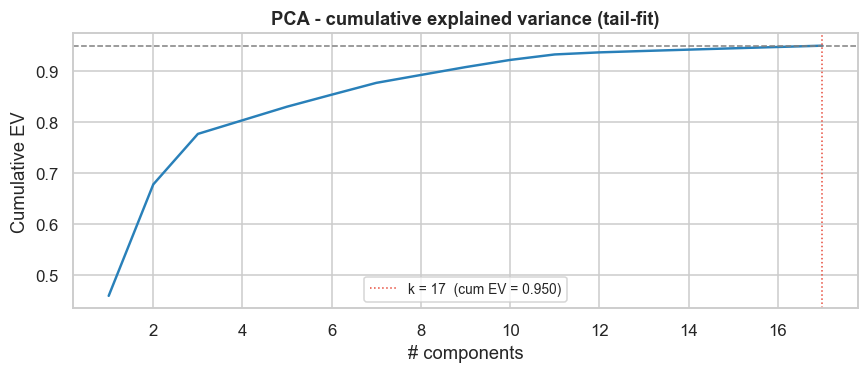

In [5]:
cum_ev = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, len(cum_ev) + 1), cum_ev, lw=1.6, color=NOMINAL_COLOR)
ax.axhline(0.95, ls='--', color='grey', lw=1)
ax.axvline(pca.n_components_, ls=':', color=ANOMALY_COLOR, lw=1,
           label=f'k = {pca.n_components_}  (cum EV = {cum_ev[-1]:.3f})')
ax.set_xlabel('# components'); ax.set_ylabel('Cumulative EV')
ax.set_title('PCA - cumulative explained variance (tail-fit)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

## 4 — Carve val / test_internal from `train_full_scaled`

Split from the boundary-check above (anomaly-safe):

- `val           = train_full[TRAIN_END : VAL_END]` — labelled. Threshold tuning only.
- `test_internal = train_full[VAL_END : ]`        — labelled. Metrics reported here.

These two blocks are used **only** for threshold tuning (val) and metric reporting (test_internal). The PCA basis itself was fit on the nominal-window tail which overlaps with val/test_internal rows — acceptable because PCA is unsupervised (no labels seen during fit); the reported metrics still estimate how well the learned basis reconstructs the drift regime that Kaggle test lives in.

In [6]:
X_val           = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END]).astype(np.float32)
y_val           = y_train_row[TRAIN_END:VAL_END].astype(np.int8)
X_test_internal = np.ascontiguousarray(train_scaled[VAL_END:]).astype(np.float32)
y_test_internal = y_train_row[VAL_END:].astype(np.int8)

print(f'val            : {X_val.shape}             anom={int(y_val.sum()):>7,}           [{TRAIN_END:,}:{VAL_END:,})')
print(f'test_internal  : {X_test_internal.shape}   anom={int(y_test_internal.sum()):>7,} [{VAL_END:,}:{n_full:,})')

val            : (2000000, 58)             anom=215,798           [10,700,000:12,700,000)
test_internal  : (2028321, 58)   anom=214,935 [12,700,000:14,728,321)


## 5 — Score val + internal-test — baseline and median-detrended

Per-split detrending (as in NB 20) — rolling-median baseline computed separately on val and internal-test so the boundary does not leak.

In [7]:
t0 = time.time()
val_scores  = score_windows(pca, X_val,           topk=None)
test_scores = score_windows(pca, X_test_internal, topk=None)
print(f'baseline score  : {time.time()-t0:.1f}s')
print(f'  val   range   : [{val_scores.min():.4f}, {val_scores.max():.4f}]')
print(f'  test  range   : [{test_scores.min():.4f}, {test_scores.max():.4f}]')

t0 = time.time()
val_scores_det  = score_windows_detrended(pca, X_val,           topk=None,
                                          detrend_window=DETREND_WIN, detrend_mode='median')
test_scores_det = score_windows_detrended(pca, X_test_internal, topk=None,
                                          detrend_window=DETREND_WIN, detrend_mode='median')
print(f'detrended score : {time.time()-t0:.1f}s  (window={DETREND_WIN} windows / '
      f'{DETREND_WIN*WINDOW_SIZE:,} rows, mode=median)')

baseline score  : 0.6s
  val   range   : [0.0180, 1180.5267]
  test  range   : [0.0176, 1.8731]


detrended score : 0.5s  (window=1000 windows / 100,000 rows, mode=median)


## 6 — Tune threshold on val, evaluate on internal-test

Both variants tuned against **ESA-corrected F0.5** (`corrected_event_f05` = Pr_ew × TNR, the Kaggle-aligned metric) on val. Report Event F0.5 and ESA-corrected F0.5 on internal-test.

Reason for switching from plain `event_f05`: that metric can be gamed by over-flagging (predictions collapse to one mega-segment → event precision = 1.0 mechanically). ESA-corrected F0.5 multiplies by row-level TNR and therefore punishes floods, matching how Kaggle actually scores the submission.

In [8]:
def row_prec_rec(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return prec, rec

rows = []
for tag, sv, st in [('baseline',  val_scores,     test_scores),
                    ('detrended', val_scores_det, test_scores_det)]:
    thr = tune_threshold(sv, y_val, metric_fn=corrected_event_f05)['threshold']
    y_hat = (st > thr).astype(np.int8)
    ef  = event_f05(y_test_internal, y_hat)
    esa = corrected_event_f05(y_test_internal, y_hat)
    rp, rr = row_prec_rec(y_test_internal, y_hat)
    pos_rate = float(y_hat.mean())
    rows.append({
        'variant'   : tag,
        'threshold' : round(float(thr), 6),
        'event_f05' : round(ef['f_score'],  4),
        'event_rec' : round(ef['recall'],   4),
        'esa_f05'   : round(esa['f_score'], 4),
        'esa_tnr'   : round(esa['tnr'],     4),
        'row_prec'  : round(rp, 4),
        'row_rec'   : round(rr, 4),
        'pos_rate'  : round(pos_rate, 4),
    })
compare = pd.DataFrame(rows)
print('--- PCA (Kaggle-specialised, full-train tail fit, ESA-tuned) — test_internal metrics ---')
print(compare.to_string(index=False))

best_row = compare.loc[compare['esa_f05'].idxmax()]
print(f"\nBest by ESA F0.5 : {best_row['variant']}  "
      f"thr={best_row['threshold']}  esa_f05={best_row['esa_f05']}  "
      f"pos_rate={best_row['pos_rate']:.4f}")

--- PCA (Kaggle-specialised, full-train tail fit, ESA-tuned) — test_internal metrics ---
  variant  threshold  event_f05  event_rec  esa_f05  esa_tnr  row_prec  row_rec  pos_rate
 baseline   0.076237     0.7971       0.44    0.797   0.9997    0.9943   0.3705    0.0395
detrended   0.052869     0.7971       0.44    0.797   0.9997    0.9920   0.2645    0.0282

Best by ESA F0.5 : baseline  thr=0.076237  esa_f05=0.797  pos_rate=0.0395


---
## Timeline — Val + Test

Standardized two-panel plot via `plot_timeline(scores, y_true, threshold, ..., log_y=True)`. Use `index` to switch the x-axis from split-local positions (default) to absolute dataset indices.

Shown variant is the winner from Section 6 (ESA F0.5) — baseline or detrended.

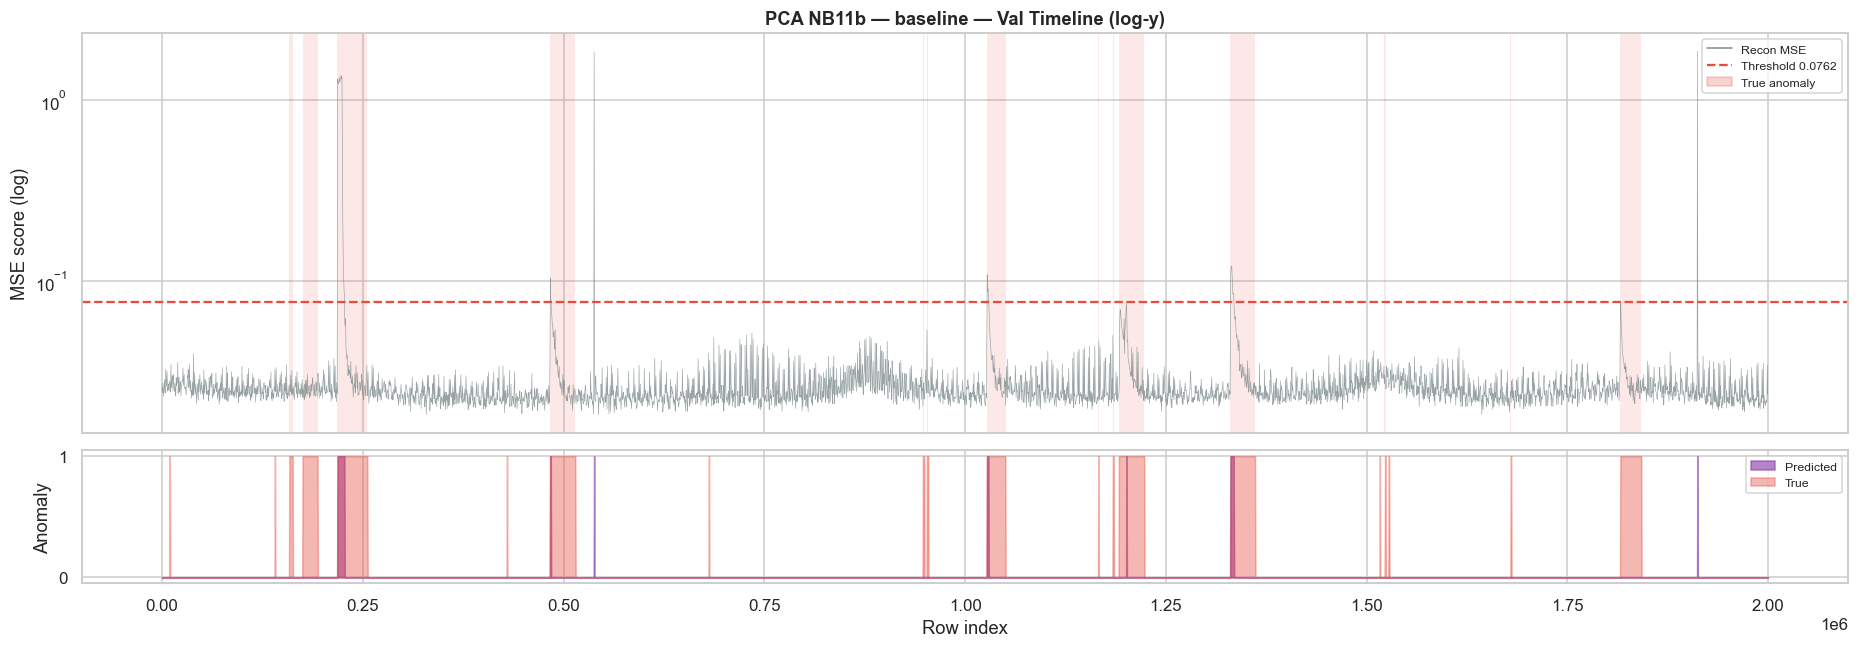

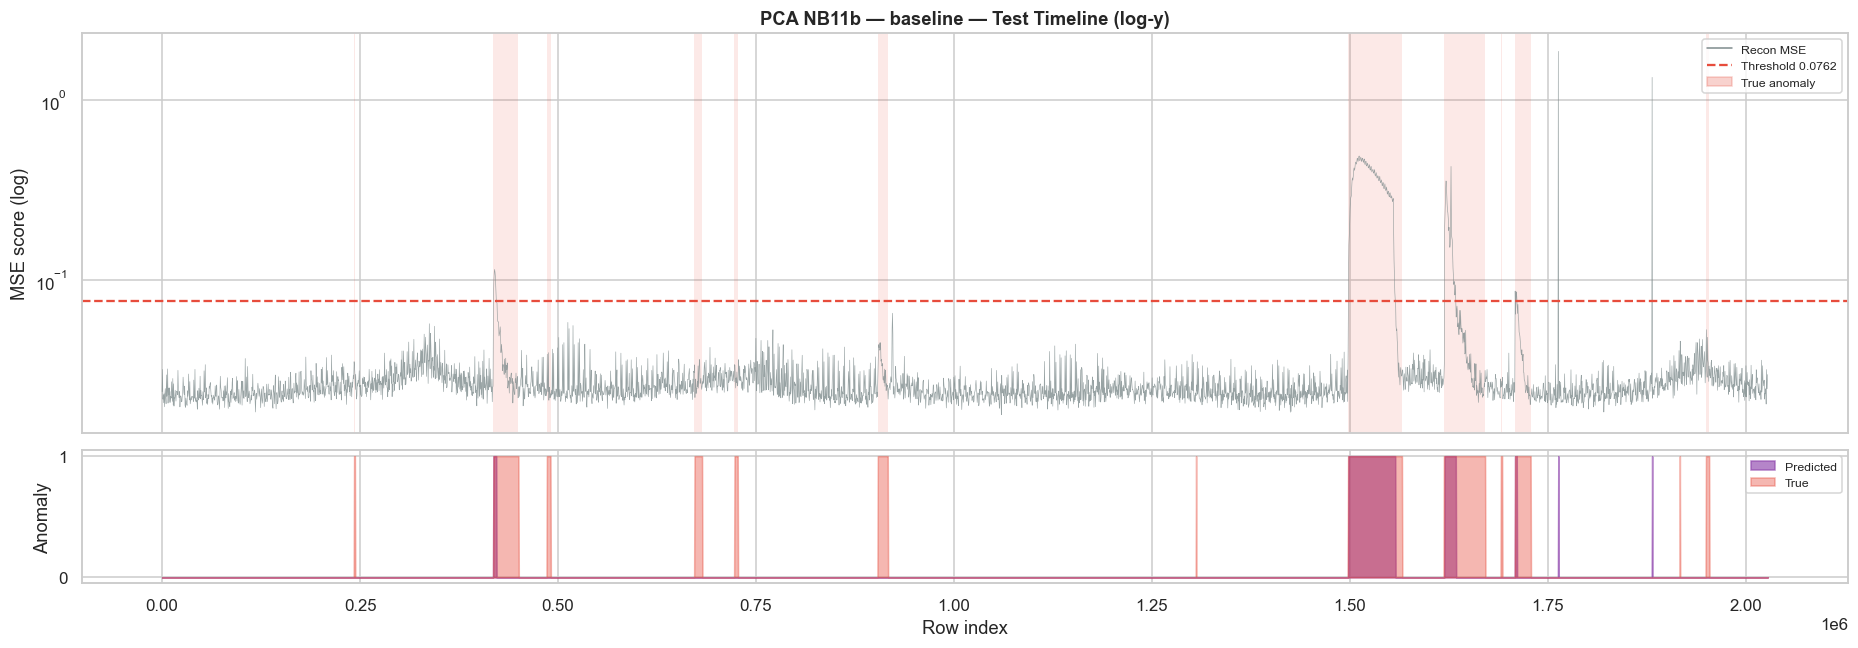

In [9]:
from sentinel.ml_logic.viz import plot_timeline

MODEL_NAME = f'PCA NB11b — {best_row["variant"]}'

# Pick the variant flagged by Section 6 as best by ESA F0.5.
if best_row['variant'] == 'baseline':
    _val_scores, _test_scores = val_scores, test_scores
else:
    _val_scores, _test_scores = val_scores_det, test_scores_det
_thr = float(best_row['threshold'])

_ = plot_timeline(_val_scores, y_val, _thr,
                  f'{MODEL_NAME} — Val Timeline (log-y)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(_test_scores, y_test_internal, _thr,
                  f'{MODEL_NAME} — Test Timeline (log-y)', log_y=True)
plt.show(); plt.close()

---
## Submission & Save model

Nach dem Review der Ergebnisse oben die gewünschten Blöcke auskommentieren und ausführen.

In [10]:
# ── Save model ──────────────────────────────────────────────────────────
# import time
# MODELS_DIR.mkdir(exist_ok=True)
# ts = time.strftime('%Y%m%d_%H%M%S')
# model_path = MODELS_DIR / f'pca_nb11b_{ts}.pkl'
# with open(model_path, 'wb') as f:
#     pickle.dump(pca, f)
# print(f'Model saved → {model_path}')


In [11]:
# Save scores — nach Review auskommentieren und ausführen
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_pca_nb11b.npy',  val_scores)
# np.save(SCORES_DIR / 'scores_test_pca_nb11b.npy', test_scores)
# print(f'Scores saved → {SCORES_DIR}/scores_{{val,test}}_pca_nb11b.npy')


In [12]:
# ── Kaggle submission ───────────────────────────────────────────────────
# best_variant  = best_row['variant']
# best_threshold = float(best_row['threshold'])
# X_kaggle = test_scaled.astype(np.float32, copy=False)
#
# print(f'Scoring Kaggle test with variant={best_variant} ...')
# if best_variant == 'baseline':
#     kaggle_scores = score_windows(pca, X_kaggle, topk=None)
# else:
#     kaggle_scores = score_windows_detrended(
#         pca, X_kaggle, topk=None,
#         detrend_window=DETREND_WIN, detrend_mode='median',
#     )
# y_kaggle = (kaggle_scores > best_threshold).astype(np.uint8)
# print(f'  positive rate : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')
#
# # _v2 suffix: keep the original cutoff-era parquets (`nb11b_pca_kaggle_<variant>.parquet`)
# # on disk for comparison rather than overwriting them.
# import time as _t
# ts = _t.strftime('%Y%m%d_%H%M%S')
# stem = f'pca_nb11b_{best_variant}_{ts}'
# out_path = default_submission_path(stem)
# submission = make_submission(
#     predictions     = y_kaggle,
#     test_ids        = test_ids,
#     out_path        = out_path,
#     validate_schema = True,
# )
# print(f'\nSubmission written: {out_path}')
# print(submission_summary(submission))
